# **Step 1 : load and explore dataset**


Download dataset and install  lib

In [63]:
!git clone https://github.com/ahmedramadan96/EALPR.git
!pip install ultralytics imagehash easyocr


fatal: destination path 'EALPR' already exists and is not an empty directory.


In [64]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

car_img = '/content/EALPR/EALPR Vechicles dataset/Vehicles'
car_lbl = '/content/EALPR/EALPR Vechicles dataset/Vehicles Labeling'

plate_img = '/content/EALPR/EALPR- Plates dataset'
plate_lbl = '/content/EALPR/EALPR- LP characters dataset/Characters Labeling'

Load images into table

In [65]:
def load_images (img_dir):

  rows = []

  for file in sorted(os.listdir(img_dir)):
    path = os.path.join(img_dir, file)
    img = cv2.imread(path)

    row = {'file' : file,
           'name' : os.path.splitext(file)[0],
           'ext' : os.path.splitext(file)[1],
           'size' : os.path.getsize(path) / 1024,
           'readable' : img is not None
           }

    if img is not None:
      row['height'], row['width']= img.shape[0:2]
      gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
      row['Brightness'] = gray.mean()                       # High value = bright_image / Low value = dark_image
      row['blur'] = cv2.Laplacian(gray, cv2.CV_64F).var()   # High value = sharp_image  / low value = blur_image

    rows.append(row)

  return pd.DataFrame(rows)

In [66]:
cars = load_images(car_img)
plates = load_images(plate_img)

print(cars.shape, plates.shape)

(2087, 9) (2069, 9)


load labels

In [67]:
def load_labels (lbl_dir):

  rows = []

  for file in sorted(os.listdir(lbl_dir)):
    if file == 'classes.txt':
      continue
    name = file[:-4]
    lines = [l for l in open(os.path.join(lbl_dir,file)).read().splitlines() if l.strip()]

    if len(lines) == 0:
     rows.append({'name' : name, 'n_fields' : 0})     # empty label file
     continue

    for line in lines :
      parts = line.split()
      p = parts + [None]*5

      rows.append({
          'name' : name ,
          'n_fields' : len(parts),
          'class_id' : p[0] ,
          'xc' : p[1] ,
          'yc' : p[2] ,
          'w' : p[3] ,
          'h' : p[4] })

      df = pd.DataFrame(rows)

      # Change the type of data text > numbers :
      for col in df.columns[2:]:
       df[col] = pd.to_numeric(df[col], errors="coerce")           # wrong type -> NaN

  return df

In [68]:
car_boxes = load_labels(car_lbl)
char_boxes = load_labels(plate_lbl)

print(car_boxes.shape, char_boxes.shape)

(2143, 7) (10802, 7)


In [69]:
classes = open(os.path.join(plate_lbl, "classes.txt"), encoding="utf-8").read().split()

char_boxes['char'] = char_boxes['class_id'].map(dict(enumerate(classes)))

In [70]:
cars.head()

,file,name,ext,size,readable,height,width,Brightness,blur
0,0001.jpg,0001,.jpg,64.938477,True,734,720,124.891619,389.179293
1,0002.jpg,0002,.jpg,66.595703,True,480,640,130.401637,1841.164973
2,0003.jpg,0003,.jpg,61.257812,True,640,480,125.274102,1932.673426
3,0004.jpg,0004,.jpg,69.980469,True,960,720,146.595447,1138.600635
4,0005.jpg,0005,.jpg,95.735352,True,720,960,129.094627,1234.096261


In [71]:
car_boxes.head()

,name,n_fields,class_id,xc,yc,w,h
0,0001,5,0,0.540278,0.546322,0.155556,0.079019
1,0002,5,0,0.491406,0.820833,0.185938,0.100000
2,0003,5,0,0.491667,0.760156,0.216667,0.067187
3,0004,5,0,0.484028,0.539062,0.123611,0.038542
4,0005,5,0,0.543750,0.799306,0.168750,0.104167


In [72]:
def add_pixels(boxes,img):

  boxes = boxes.merge(img[['name','width','height']], on ='name', how='left')

  boxes['w_px'] = boxes['w'] * boxes['width']
  boxes['h_px'] = boxes['h'] * boxes['height']
  boxes['aspect'] = boxes['w_px'] / boxes['h_px'].replace(0, np.nan)

  return boxes

In [73]:
car_boxes = add_pixels(car_boxes, cars)
char_boxes = add_pixels(char_boxes, plates)

Summary stats.

In [74]:
print(cars.head(3))
print(char_boxes.head(3))
print(plates.head(3))
print(car_boxes.head(3))

       file  name   ext       size  readable  height  width  Brightness  \
0  0001.jpg  0001  .jpg  64.938477      True     734    720  124.891619   
1  0002.jpg  0002  .jpg  66.595703      True     480    640  130.401637   
2  0003.jpg  0003  .jpg  61.257812      True     640    480  125.274102   

          blur  
0   389.179293  
1  1841.164973  
2  1932.673426  
                   name  n_fields  class_id        xc        yc         w  \
0  0001_license_plate_1         5      24.0  0.158537  0.580882  0.105691   
1  0001_license_plate_1         5      18.0  0.256098  0.602941  0.056911   
2  0001_license_plate_1         5      19.0  0.353659  0.602941  0.089431   

          h char  width  height  w_px  h_px    aspect  
0  0.308824    ٧  123.0    68.0  13.0  21.0  0.619048  
1  0.323529    ١  123.0    68.0   7.0  22.0  0.318182  
2  0.352941    ٢  123.0    68.0  11.0  24.0  0.458333  
                       file                  name   ext       size  readable  \
0  0001_license_pl

In [75]:
cars.info()
plates.info()
char_boxes.info()

cars.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   file        2087 non-null   object 
 1   name        2087 non-null   object 
 2   ext         2087 non-null   object 
 3   size        2087 non-null   float64
 4   readable    2087 non-null   bool   
 5   height      2087 non-null   int64  
 6   width       2087 non-null   int64  
 7   Brightness  2087 non-null   float64
 8   blur        2087 non-null   float64
dtypes: bool(1), float64(3), int64(2), object(3)
memory usage: 132.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2069 entries, 0 to 2068
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   file        2069 non-null   object 
 1   name        2069 non-null   object 
 2   ext         2069 non-null   object 
 3   size        2069 non-null   float64
 4   readable    2

,size,height,width,Brightness,blur
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,96.443301,904.194058,883.421658,101.110391,663.730380
std,60.259349,243.165512,200.906683,29.729775,903.789428
min,9.709961,249.000000,240.000000,13.620720,3.603305
25%,62.341309,720.000000,750.000000,81.211194,176.170792
50%,84.428711,960.000000,900.000000,104.834044,382.432688
75%,115.632812,1080.000000,1080.000000,122.530424,794.027826
max,1149.100586,3024.000000,4032.000000,180.424792,12822.964544


In [76]:
print(char_boxes.eq(0).sum())
print(car_boxes.eq(0).sum())

name          0
n_fields      5
class_id    465
xc            0
yc            0
w             0
h             1
char          0
width         0
height        0
w_px          0
h_px          1
aspect        0
dtype: int64
name           0
n_fields       0
class_id    2143
xc             0
yc             0
w              0
h              0
width          0
height         0
w_px           0
h_px           0
aspect         0
dtype: int64


In [77]:
char_boxes[['w_px', 'h_px', 'aspect']].describe()

# Showes boxes with zero height - big aspect ratio => Since in char. box expected narrow tall boxes so small aspect ratio (< 1)

,w_px,h_px,aspect
count,10797.000000,10797.000000,10796.000000
mean,17.273687,30.150134,0.600481
std,9.459916,15.066094,0.219496
min,1.000000,0.000000,0.166667
25%,11.000000,21.000000,0.457143
50%,16.000000,27.000000,0.555556
75%,21.000000,36.000000,0.735681
max,135.000000,185.000000,2.062500


In [78]:
labels = char_boxes[char_boxes['n_fields'] > 0]

print("lines with wrong number of fields:", (labels['n_fields'] != 5).sum())
print("missing values:", labels[['class_id', 'xc', 'yc', 'w', 'h']].isna().sum().sum())
print("class id out of range:", (~labels['class_id'].between(0, len(classes) - 1)).sum())
print("coordinates outside 0-1:", (~labels['xc'].between(0, 1) | ~labels['yc'].between(0, 1)).sum())
print("width with zero values:",labels['w'].eq(0).sum())
print("height with zero values:",labels['h'].eq(0).sum())

print(cars['ext'].value_counts())



lines with wrong number of fields: 0
missing values: 0
class id out of range: 0
coordinates outside 0-1: 0
width with zero values: 0
height with zero values: 1
ext
.jpg     2031
.JPG       54
.jpeg       2
Name: count, dtype: int64


Show samples with their boxes

In [79]:
cars.head(3)

,file,name,ext,size,readable,height,width,Brightness,blur
0,0001.jpg,0001,.jpg,64.938477,True,734,720,124.891619,389.179293
1,0002.jpg,0002,.jpg,66.595703,True,480,640,130.401637,1841.164973
2,0003.jpg,0003,.jpg,61.257812,True,640,480,125.274102,1932.673426


In [80]:
def show_samples(img_dir, images,boxes,n=6):

  names = np.random.choice(images[images['readable']]['name'],n,replace = False) # replace = False => no repeat

  plt.figure(figsize=(15,6))
  for i , name in enumerate(names):
    file = images[images['name']== name]['file'].values[0]
    file_path = os.path.join(img_dir,file)
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h,w = img.shape[:2]

    for _,b in boxes[(boxes["name"] == name) & (boxes["n_fields"] == 5)].iterrows():
      x1,y1 = int((b['xc']- b['w']/2)* w), int((b['yc']- b['h']/2)* h)
      x2,y2 = int((b['xc']+ b['w']/2)* w), int((b['yc']+ b['h']/2)* h)
      cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0) ,2)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis('off')

  plt.show()


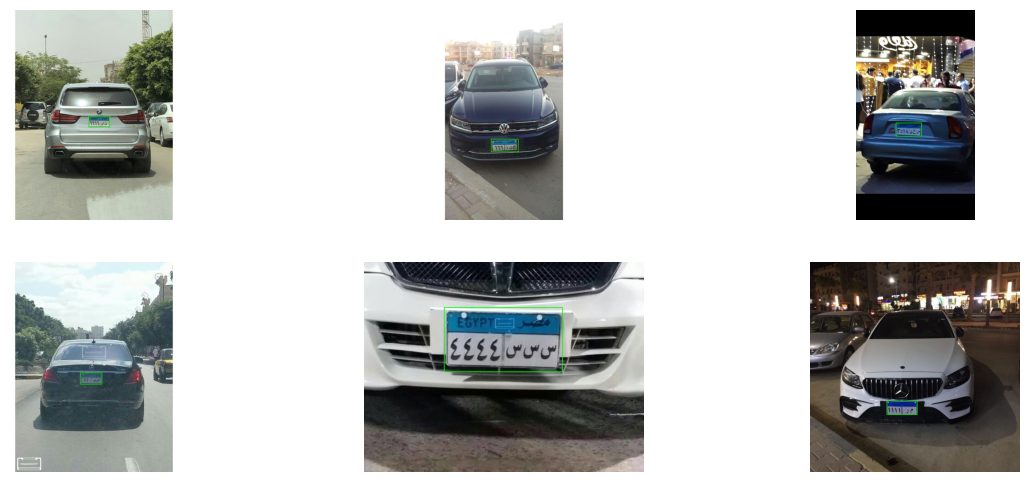

In [81]:
show_samples(car_img, cars, car_boxes)

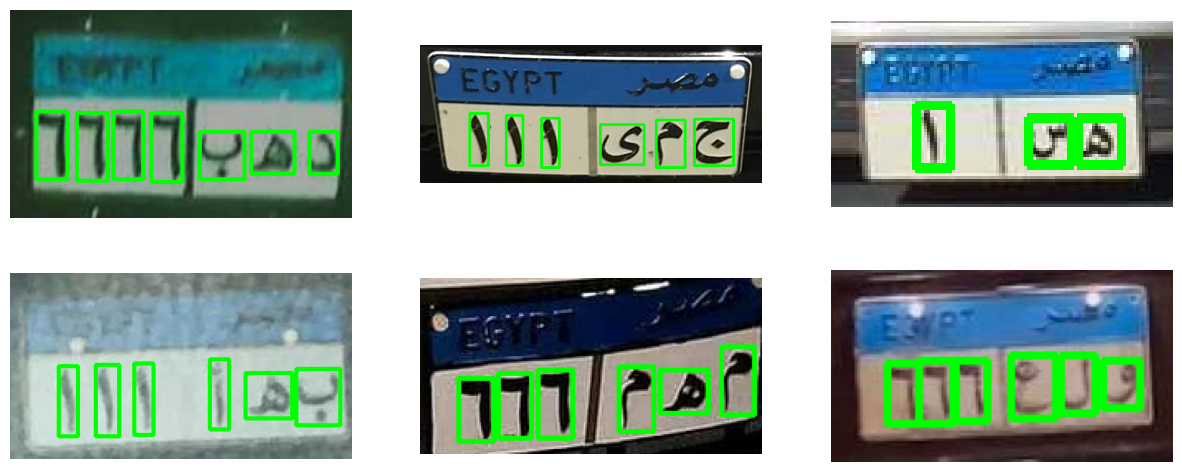

In [82]:
show_samples(plate_img, plates, char_boxes)

# **Step 2 : Duplicates**

Exact duplicates with same file size

In [83]:
import hashlib

def file_hash(path):
    return hashlib.md5(open(path, "rb").read()).hexdigest()

In [84]:
cars['md5'] = [file_hash(os.path.join(car_img,f)) for f in cars['file']]
plates['md5'] = [file_hash(os.path.join(plate_img,f)) for f in plates['file']]

dup_cars = cars["md5"].duplicated().sum()
dup_plates = plates["md5"].duplicated().sum()

print(f"exact duplicate cars: {dup_cars} ({dup_cars / len(cars) * 100:.1f}%)")
print(f"exact duplicate plates: {dup_plates} ({dup_plates / len(plates) * 100:.1f}%)")


exact duplicate cars: 4 (0.2%)
exact duplicate plates: 55 (2.7%)


Near duplicates (same photo, resized or re-saved)

In [85]:
import imagehash
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True        # a few photos are slightly cut off

cars = cars[cars["readable"]].reset_index(drop=True)          # unreadable images can't be hashed

hashes = np.array([imagehash.phash(Image.open(os.path.join(car_img,f ))).hash.flatten() for f in cars["file"]])

group = np.full(len(cars), -1)

for i in range(len(cars)):
    if group[i] == -1:
        dist = (hashes != hashes[i]).sum(axis=1)               # Hamming distance to every image
        group[(dist <= 4) & (group == -1)] = i                 # <= 4 bits different = same photo


cars["group"] = group
sizes = cars["group"].value_counts()
print("images that have a near duplicate:", sizes[sizes > 1].sum())


images that have a near duplicate: 283


Show a few near-duplicate pairs

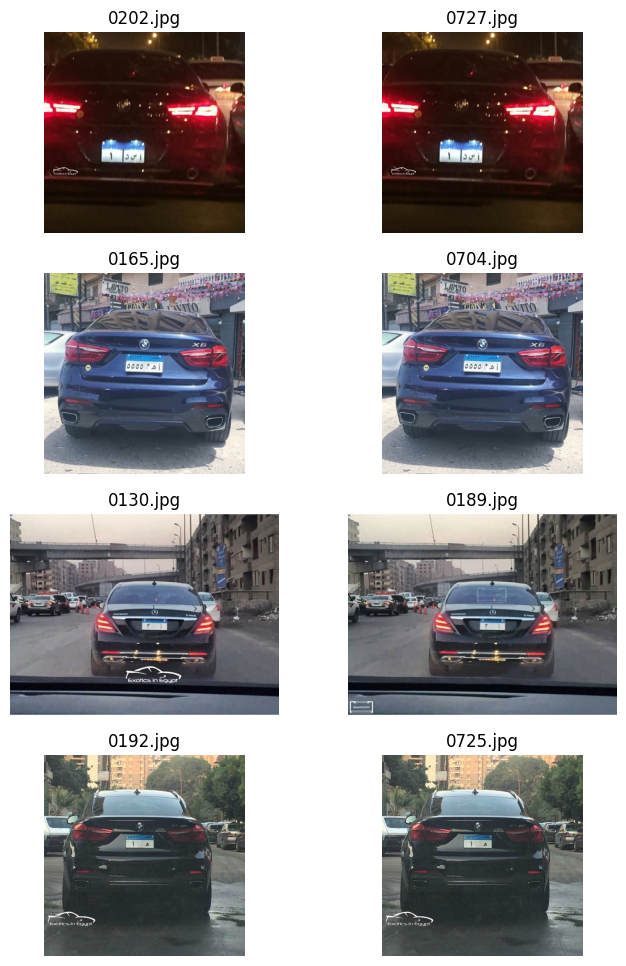

In [86]:
dup_groups = sizes[sizes > 1].index[:4]

plt.figure(figsize=(8, 12))

for i, g in enumerate(dup_groups):
    files = cars[cars["group"] == g]["file"].values[:2]

    for j, f in enumerate(files):
        img = cv2.cvtColor(cv2.imread(os.path.join(car_img, f)), cv2.COLOR_BGR2RGB)
        plt.subplot(4, 2, i * 2 + j + 1)
        plt.imshow(img)
        plt.title(f)
        plt.axis("off")

plt.show()

Drop exact - Near duplicates

In [87]:
char_boxes.duplicated(["name", "class_id", "xc", "yc", "w", "h"]).sum()

# drop exact duplicates
cars = cars.drop_duplicates("md5", keep="first")
plates = plates.drop_duplicates("md5", keep="first")

#drop near duplicates
cars = cars.drop_duplicates('group', keep='first')
plates = plates[plates['name'].str[:4].isin(cars['name'])]    # drop plates of the removed cars

# keep only the boxes whose image is still in the table
car_boxes = car_boxes[car_boxes["name"].isin(cars["name"])]
char_boxes = char_boxes[char_boxes["name"].isin(plates["name"])]

print(cars.shape, plates.shape)


(1940, 11) (1921, 10)


In [88]:
plates.head()

,file,name,ext,size,readable,height,width,Brightness,blur,md5
0,0001_license_plate_1.png,0001_license_plate_1,.png,17.120117,True,68.0,123.0,126.373505,1292.570394,265d69f3e4b84f52df01ba6e88f5355a
1,0002_license_plate_1.png,0002_license_plate_1,.png,17.233398,True,62.0,130.0,144.174814,6318.092104,83db7f96988c25cef5046a8d1cc56904
2,0003_license_plate_1.png,0003_license_plate_1,.png,13.255859,True,57.0,119.0,97.157600,6267.528574,9c97279e4fb7c1353ccc5fe073c8de72
3,0004_license_plate_1.png,0004_license_plate_1,.png,8.335938,True,45.0,96.0,107.676852,3498.976556,4d425cdf4477fe8359e6e281f7d8cbf8
4,0005_license_plate_1.png,0005_license_plate_1,.png,26.305664,True,88.0,170.0,195.097126,3631.709325,19c27c74ee102b7e02c1b3999c4ad1f6


# Step 3 : Missing values

find missing values

In [89]:
unreadable = plates[~plates["readable"]]["name"]
no_label = set(plates["name"]) - set(char_boxes["name"])
empty = char_boxes[char_boxes["n_fields"] == 0]["name"]

print(f"unreadable plate images: {len(unreadable)} ({len(unreadable) / len(plates) * 100:.1f}%)")
print(f"plates without a label file: {len(no_label)} ({len(no_label) / len(plates) * 100:.1f}%)")
print(f"empty label files: {len(empty)} ({len(empty) / len(plates) * 100:.1f}%)")


unreadable plate images: 1 (0.1%)
plates without a label file: 81 (4.2%)
empty label files: 5 (0.3%)


Delete missing values

In [90]:
bad = set(unreadable) | no_label | set(empty)

plates = plates[~plates["name"].isin(bad)]
char_boxes = char_boxes[~char_boxes["name"].isin(bad)]

print("plates left:", len(plates))

plates left: 1835


# Step  4 : Outliers

IQR and z-score on the box features

In [91]:
from scipy.stats import zscore

def iqr_outliers(col, k=1.5):
    q1, q3 = col.quantile(0.25), col.quantile(0.75)
    iqr = q3 - q1
    return (col < q1 - k * iqr) | (col > q3 + k * iqr)

In [92]:
for col in ['w_px','h_px','aspect']:
  iqr_out = iqr_outliers(char_boxes[col])
  zscore_outliers = np.abs(zscore(char_boxes[col], nan_policy='omit')) > 3
  print(f"{col}: IQR {iqr_out.sum()} ({iqr_out.mean() * 100:.1f}%)   Z-score {zscore_outliers.sum()} ({zscore_outliers.mean() * 100:.1f}%)")



w_px: IQR 339 (3.4%)   Z-score 138 (1.4%)
h_px: IQR 337 (3.3%)   Z-score 154 (1.5%)
aspect: IQR 118 (1.2%)   Z-score 36 (0.4%)


Boxplot

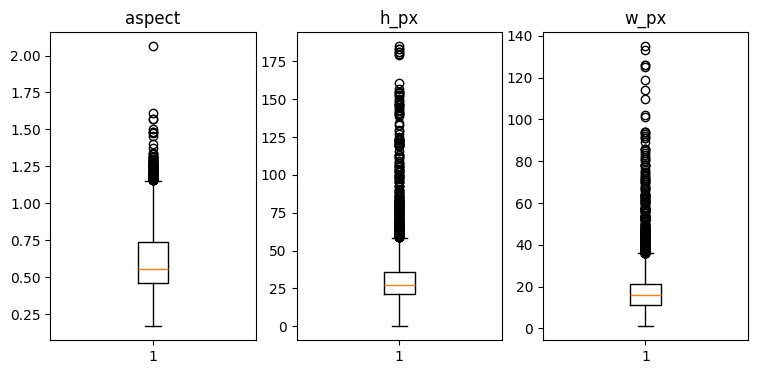

In [93]:
cols = ["aspect", "h_px", "w_px"]

plt.figure(figsize=(9,4))

for i, col in enumerate(cols):
  plt.subplot(1,3,i+1)
  plt.boxplot(char_boxes[col].dropna())
  plt.title(col)

plt.show()

show samples from the detected outliers

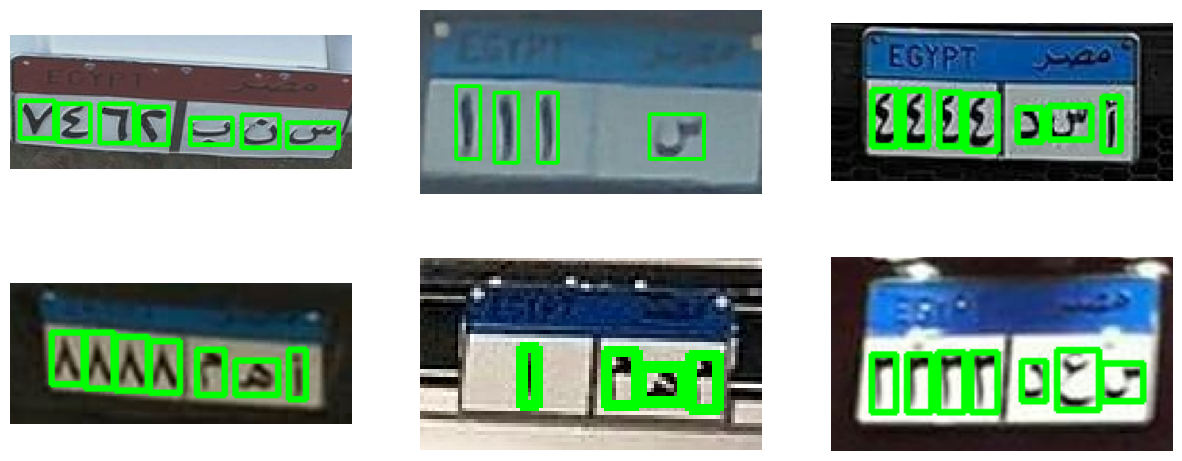

In [94]:
# IQR Outliers:
flagged_iqr = char_boxes[iqr_outliers(char_boxes['aspect'])]

show_samples(plate_img, plates[plates['name'].isin(flagged_iqr['name'])],char_boxes)

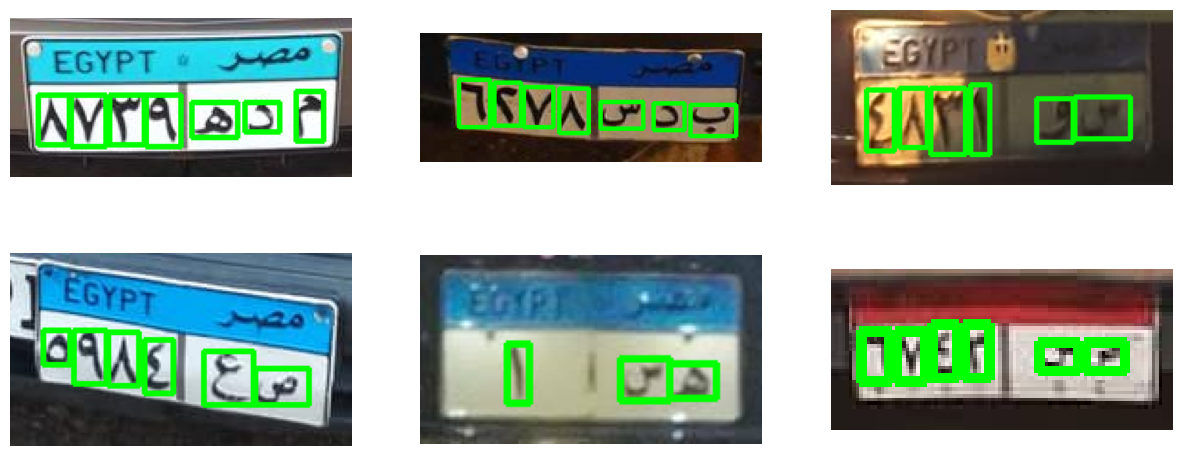

In [95]:
# Z-Score Outliers:
flagged_zscore = char_boxes[np.abs(zscore(char_boxes['aspect'], nan_policy='omit')) > 3]

show_samples(plate_img, plates[plates['name'].isin(flagged_zscore['name'])],char_boxes)


Clip boxes past the edge of the plate image

In [96]:
broken = char_boxes[(char_boxes['w']<=0) | (char_boxes['h']<=0)]['name']
plates = plates[~plates['name'].isin(broken)]
char_boxes = char_boxes[~char_boxes['name'].isin(broken)]

print("plates removed:", broken.nunique())

plates removed: 1


In [97]:
def clip_boxes (boxes):
  x1 = (boxes['xc'] - (boxes['w'] / 2)).clip(0,1)
  y1 = (boxes['yc'] - (boxes['h'] / 2)).clip(0,1)
  x2 = (boxes['xc'] + (boxes['w'] / 2)).clip(0,1)
  y2 = (boxes['yc'] + (boxes['h'] / 2)).clip(0,1)

  boxes['xc'] = (x1 + x2) / 2
  boxes['yc'] = (y1 + y2) / 2
  boxes['w'] = (x2 - x1)
  boxes['h'] = (y2 - y1)

  return boxes

In [98]:
char_boxes = clip_boxes(char_boxes)
car_boxes = clip_boxes(car_boxes)

show samples of Blurry & Dark images

In [99]:
blurry = cars[cars["blur"] < 50]
dark = cars[cars["Brightness"] < 40]

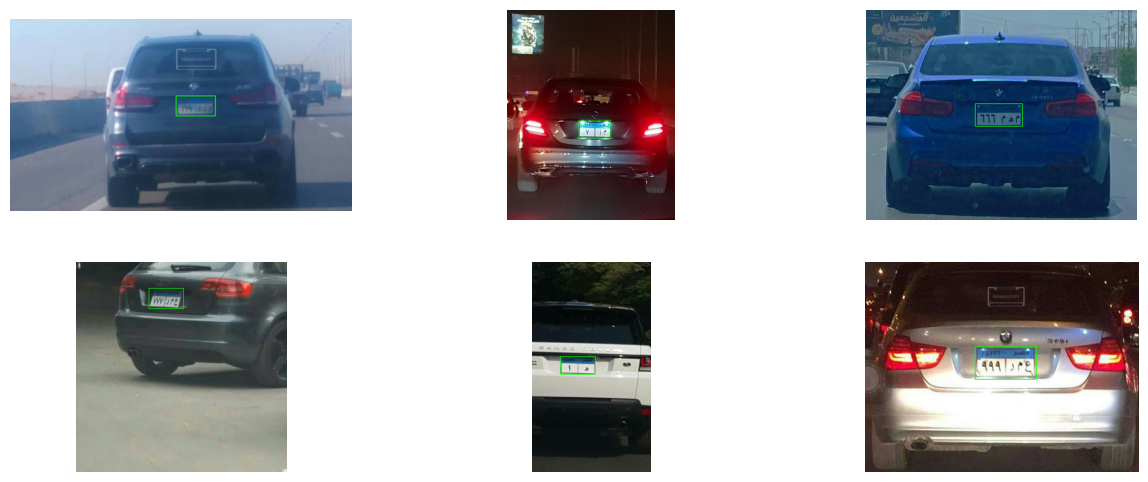

In [100]:
show_samples(car_img, blurry, car_boxes)

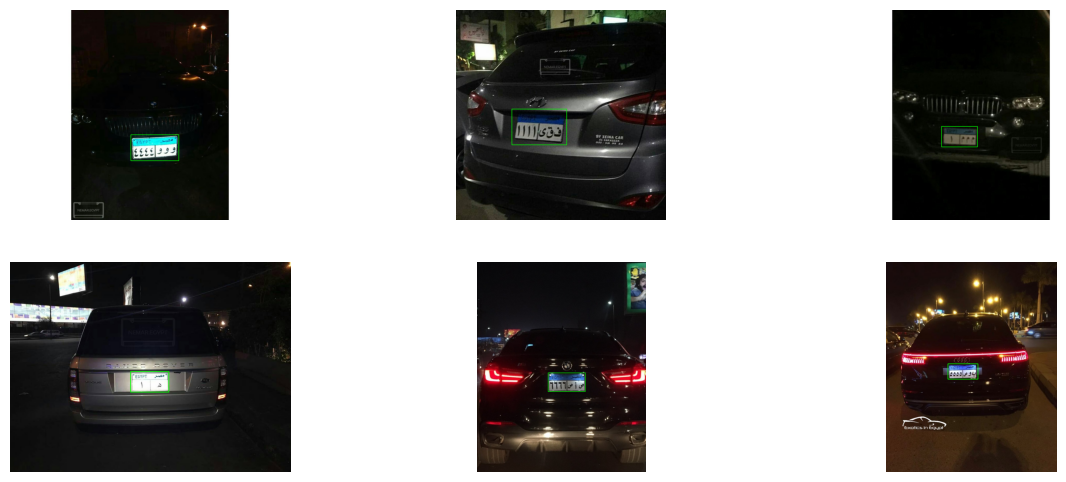

In [101]:
show_samples(car_img, dark, car_boxes)

# Step 5 : Visualization

Give every Arabic character an English name to use them in plots

In [102]:
import seaborn as sns

# matplotlib can't join Arabic letters, so use Latin names in the plots
latin = {"أ": "alef", "ب": "beh", "ج": "geem", "د": "dal", "ر": "reh", "س": "seen", "ص": "sad",
         "ط": "tah", "ع": "ain", "ف": "feh", "ق": "qaf", "ل": "lam", "م": "meem", "ن": "noon",
         "ھ": "heh", "و": "waw", "ى": "yeh", "٠": "0", "١": "1", "٢": "2", "٣": "3", "٤": "4",
         "٥": "5", "٦": "6", "٧": "7", "٨": "8", "٩": "9"}

char_boxes["latin"] = char_boxes["char"].map(latin)

characters distribution

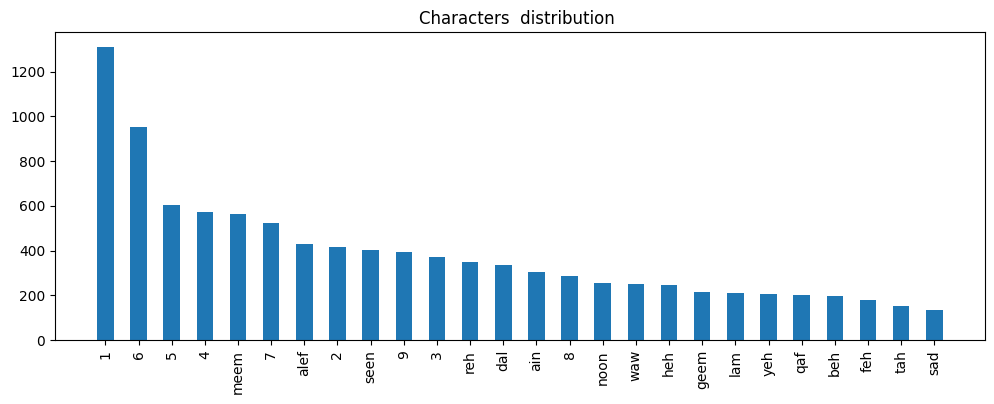

In [103]:
plt.figure(figsize=(12, 4))
plt.bar(char_boxes['latin'].value_counts().index  , char_boxes['latin'].value_counts(),width = 0.5)
plt.xticks(rotation=90)
plt.title("Characters  distribution ")
plt.show()

Character height in pixels

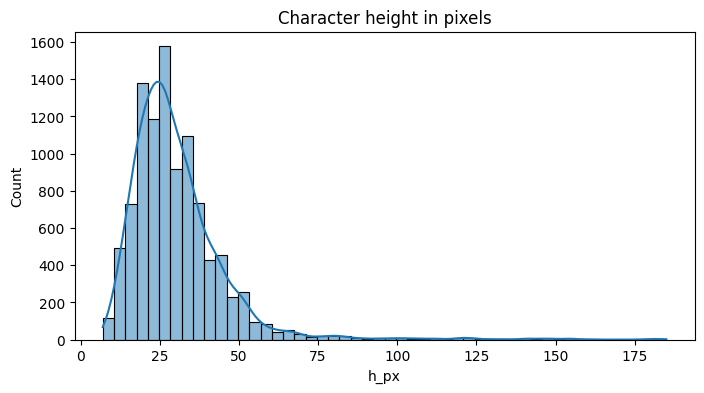

In [104]:
plt.figure(figsize=(8, 4))
sns.histplot(char_boxes["h_px"], bins=50, kde=True)
plt.title("Character height in pixels")
plt.show()

In [105]:
char_boxes["h_yolo"] = char_boxes["h_px"] * 320 / char_boxes[["width", "height"]].max(axis=1)

print("characters under 8 px for YOLO:", (char_boxes["h_yolo"] < 8).sum())
print(char_boxes["h_yolo"].describe())

characters under 8 px for YOLO: 0
count    10080.000000
mean        53.635718
std          9.544392
min         23.378995
25%         46.545455
50%         54.901961
75%         60.377358
max         96.856187
Name: h_yolo, dtype: float64


Plate width vs height

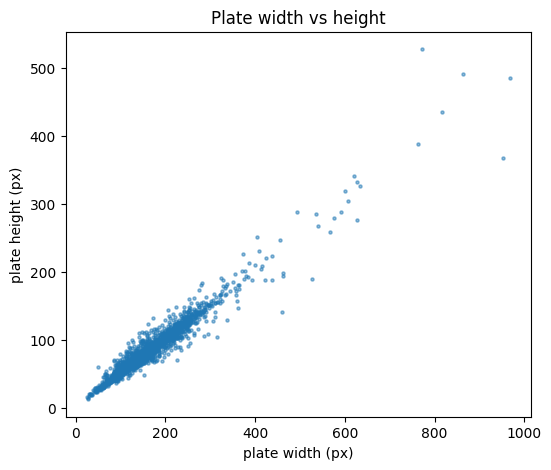

In [106]:
plt.figure(figsize=(6, 5))
plt.scatter(car_boxes["w_px"], car_boxes["h_px"], s=5, alpha=0.5)
plt.xlabel("plate width (px)")
plt.ylabel("plate height (px)")
plt.title("Plate width vs height")
plt.show()

plates placement respect to the image

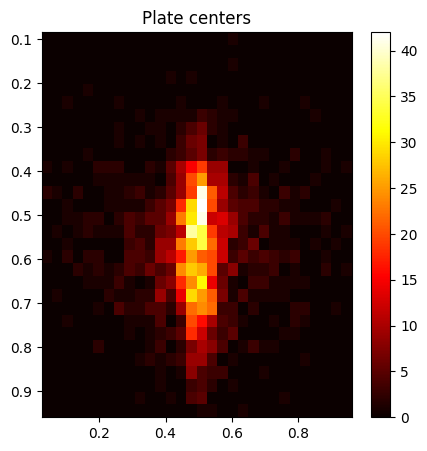

In [107]:
plt.figure(figsize=(5, 5))
plt.hist2d(car_boxes["xc"], car_boxes["yc"], bins=30, cmap="hot")
plt.gca().invert_yaxis()                                 # flip the y-axis since in images y-axis starts from top
plt.title("Plate centers")
plt.colorbar()
plt.show()

Problems found in the data

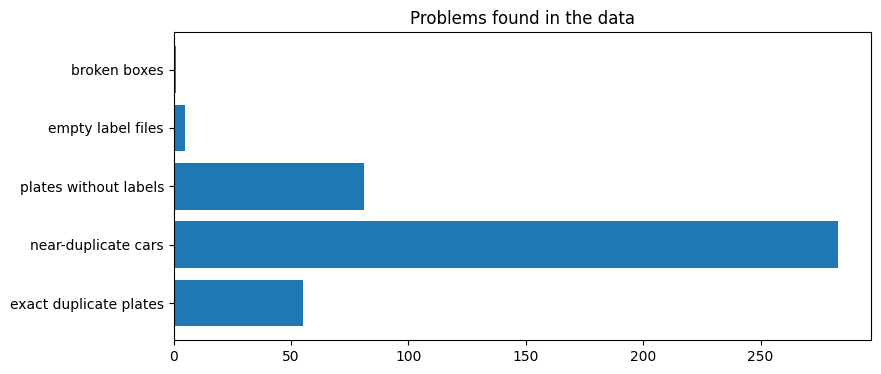

In [108]:
problems = {"exact duplicate plates": dup_plates, "near-duplicate cars": int(sizes[sizes > 1].sum()),
            "plates without labels": len(no_label), "empty label files": len(empty),
            "broken boxes": broken.nunique()}

plt.figure(figsize=(9, 4))
plt.barh(list(problems.keys()), list(problems.values()))
plt.title("Problems found in the data")
plt.show()

# Step  6 : Imbalance, split and YOLO Folders

measure the imbalance

In [109]:
counts = char_boxes["char"].value_counts()

print(len(counts))


26


In [110]:
char_boxes['char'].nunique()

26

In [111]:
new_classes = [c for c in classes if c != "٠"]

new_id_set = {}
for i,c in enumerate(new_classes):
  new_id_set[c] = i

char_boxes['new_id'] = char_boxes['char'].map(new_id_set)

char_boxes.head()

,name,n_fields,class_id,xc,yc,w,h,char,width,height,w_px,h_px,aspect,latin,h_yolo,new_id
0,0001_license_plate_1,5,24.0,0.158537,0.580882,0.105691,0.308824,٧,123.0,68.0,13.0,21.0,0.619048,7,54.634146,23
1,0001_license_plate_1,5,18.0,0.256098,0.602941,0.056911,0.323529,١,123.0,68.0,7.0,22.0,0.318182,1,57.235772,17
2,0001_license_plate_1,5,19.0,0.353659,0.602941,0.089431,0.352941,٢,123.0,68.0,11.0,24.0,0.458333,2,62.439024,18
3,0001_license_plate_1,5,23.0,0.459350,0.610294,0.089431,0.338235,٦,123.0,68.0,11.0,23.0,0.478261,6,59.837398,22
4,0001_license_plate_1,5,13.0,0.593496,0.625000,0.113821,0.279412,ن,123.0,68.0,14.0,19.0,0.736842,noon,49.430894,13


In [112]:
from sklearn.model_selection import train_test_split

train, val_n_test = train_test_split(cars, test_size=0.3, random_state=42)
val, test = train_test_split(val_n_test, test_size=1/3, random_state=42)

split_of = {}

split_of.update({ n : 'train' for n in train['name']})
split_of.update({ n : 'val' for n in val['name']})
split_of.update({ n : 'test' for n in test['name']})

cars['split'] = cars['name'].map(split_of)
plates['split'] = plates['name'].str[:4].map(split_of)

print(cars["split"].value_counts())
print('----------------------------')
print(plates["split"].value_counts())

split
train    1358
val       388
test      194
Name: count, dtype: int64
----------------------------
split
train    1288
val       356
test      190
Name: count, dtype: int64


Oversample plates with rare characters (train only)

In [113]:
import math

target = 300
train_names = plates[plates["split"] == "train"]["name"]
train_counts = char_boxes[char_boxes["name"].isin(train_names)]["char"].value_counts()


In [114]:
train_counts

,count
char,
١,921
٦,673
٤,394
٥,391
م,381
٧,379
٢,320
أ,291
س,284


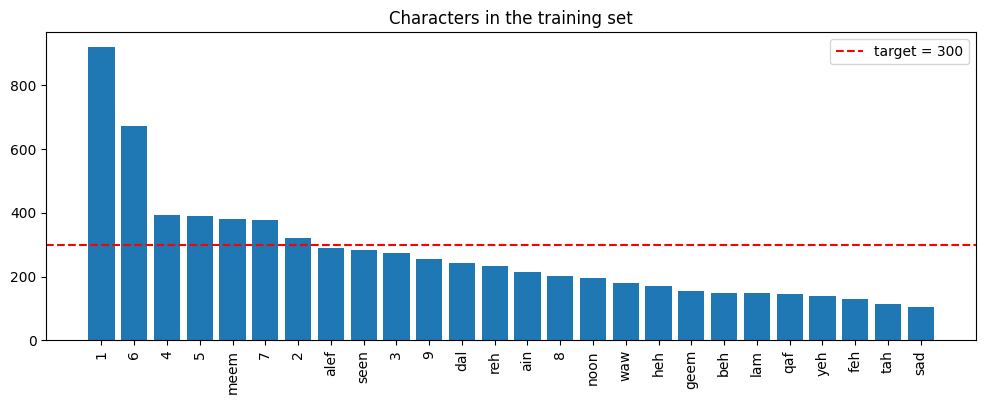

In [115]:
counts = train_counts.rename(index=latin)       # Arabic -> Latin names for the plot

plt.figure(figsize=(12, 4))
plt.bar(counts.index, counts.values)
plt.axhline(target, color="red", linestyle="--", label=f"target = {target}")
plt.xticks(rotation=90)
plt.title("Characters in the training set")
plt.legend()
plt.show()

In [116]:
repeat = {}

for name in train_names:
    chars = char_boxes[char_boxes["name"] == name]["char"]
    repeat[name] = max(min(3, math.ceil(target / train_counts[c])) for c in chars)


print(pd.Series(repeat).value_counts())

2    650
3    581
1     57
Name: count, dtype: int64


Write the YOLO folders and data.yaml files

In [117]:
import shutil

def export_yolo(images, boxes, img_dir, id_col, out_dir, names, repeat={}):

  for _, row in images.iterrows():
    # Build the folder structure for yolo ex. train -> images/ labels/
    split = row['split']

    img_path = f'{out_dir}/{split}/images'
    label_path = f'{out_dir}/{split}/labels'

    os.makedirs(img_path, exist_ok = True)
    os.makedirs(label_path, exist_ok = True)

    # prepare labels for each image
    b = boxes[boxes['name'] == row['name']]
    lines = []
    for _, r in b.iterrows():
      lines.append(f"{int(r[id_col])} {r['xc']:.6f} {r['yc']:.6f} {r['w']:.6f} {r['h']:.6f}")

    # how many copies to be added for each image
    if split == 'train' :
      n = repeat.get(row['name'], 1)
    else :
      n = 1

    # Copy the image and write the labels
    for k in range(n):
      if k == 0:
        new = row['name']               # ex: 0001
      else:
        new = f"{row['name']}_copy{k}"  # ex: 0001_copy1

      shutil.copy( os.path.join(img_dir,row['file']) , f"{img_path}/{new}{row['ext'].lower()}" )    # shutil.copy(source, destination)
      open(f"{label_path}/{new}.txt", 'w').write('\n'.join(lines))

  # Data.yaml
  with open(f"{out_dir}/data.yaml", "w") as f:
      f.write(f"path: {out_dir}\ntrain: train/images\nval: val/images\ntest: test/images\n")
      f.write(f"names: {names}\n")


In [118]:
export_yolo(cars, car_boxes, car_img, "class_id", "/content/plates_yolo", ["plate"])

export_yolo(plates, char_boxes, plate_img, "new_id", "/content/chars_yolo",
            [latin[c] for c in new_classes], repeat)

print(open("/content/chars_yolo/data.yaml").read())

path: /content/chars_yolo
train: train/images
val: val/images
test: test/images
names: ['alef', 'beh', 'geem', 'dal', 'reh', 'seen', 'sad', 'tah', 'ain', 'feh', 'qaf', 'lam', 'meem', 'noon', 'heh', 'waw', 'yeh', '1', '2', '3', '4', '5', '6', '7', '8', '9']



# Step 7 : Training

In [119]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Train the Plate Detector Model

In [120]:
# from ultralytics import YOLO

# plate_model = YOLO("yolo11s.pt")

# results  = plate_model.train(
#     data = '/content/plates_yolo/data.yaml',
#     epochs = 50,
#     imgsz = 640,
#     batch = 16,
#     name = 'plate_detector',
#     patience = 10,
#     weight_decay = 0.0005,
#     project = "/content/drive/MyDrive/runs"
# )

In [121]:
# plate_dir = plate_model.trainer.save_dir      # exact folder, so the path is never mistyped
# print(plate_dir)

Train the character detector (OCR)

In [122]:
# char_model = YOLO("yolo11s.pt")

# results  = char_model.train(
#     data = '/content/chars_yolo/data.yaml',
#     epochs = 80,
#     imgsz = 320,
#     batch = 32,
#     name = 'char_detector',
#     patience = 15,
#     fliplr = 0.0, # don't flip Arabic characters
#     degrees = 5,
#     hsv_v = 0.5,     # Brightness changes
#     project = "/content/drive/MyDrive/runs"
# )


In [123]:
# char_dir = char_model.trainer.save_dir
# print(char_dir)

Set Pathes to results folder

In [124]:
plate_dir = '/content/drive/MyDrive/runs/plate_detector-2'

char_dir = '/content/drive/MyDrive/runs/char_detector'

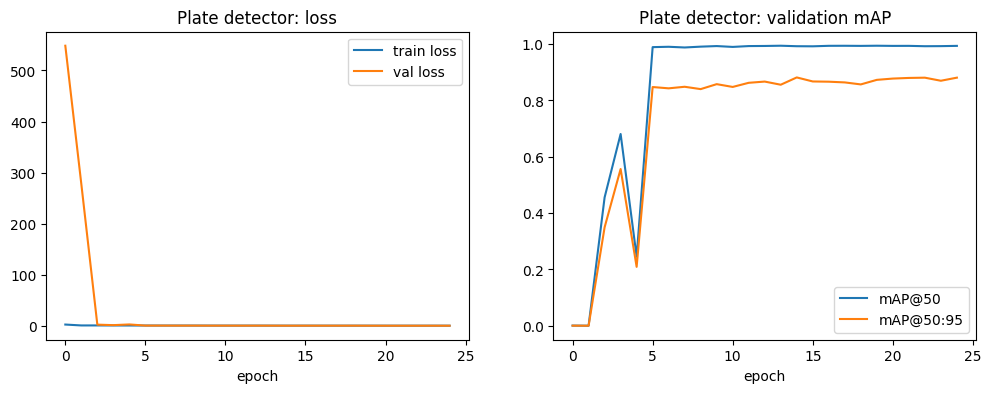

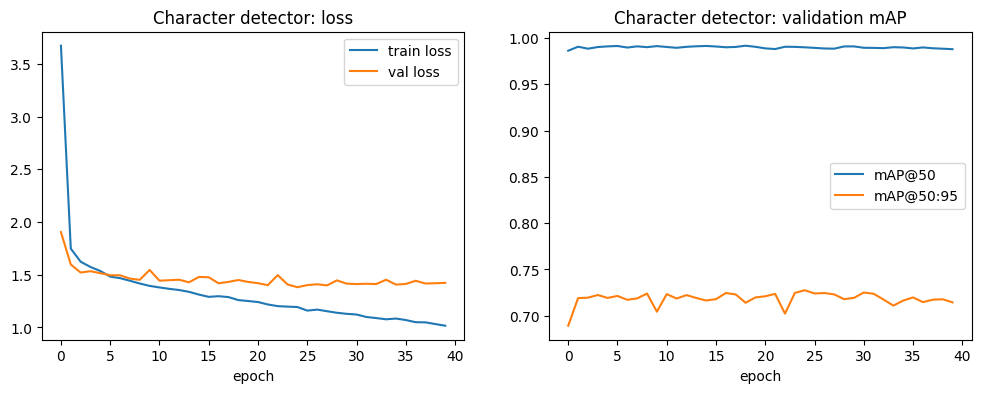

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_curves(run_dir, title):
    df = pd.read_csv(f"{run_dir}/results.csv")
    df.columns = df.columns.str.strip()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(df["train/box_loss"] + df["train/cls_loss"], label="train loss")
    plt.plot(df["val/box_loss"] + df["val/cls_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.title(title + ": loss")

    plt.subplot(1, 2, 2)
    plt.plot(df["metrics/mAP50(B)"], label="mAP@50")
    plt.plot(df["metrics/mAP50-95(B)"], label="mAP@50:95")
    plt.xlabel("epoch")
    plt.legend()
    plt.title(title + ": validation mAP")

    plt.show()


plot_curves(plate_dir, "Plate detector")
plot_curves(char_dir, "Character detector")

# Step 8 : Evaluation

In [126]:
from ultralytics import YOLO

plate_model = YOLO(f"{plate_dir}/weights/best.pt")
char_model = YOLO(f"{char_dir}/weights/best.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


For Plate Detector

In [127]:
plate_metrics = plate_model.val(data="/content/plates_yolo/data.yaml", split="test")
print('Plate_detector')
print(f"mAP@50: {plate_metrics.box.map50:.3f}")
print(f"mAP@50:95: {plate_metrics.box.map:.3f}")
print(f"Precision: {plate_metrics.box.mp:.3f}")
print(f"Recall: {plate_metrics.box.mr:.3f}")


Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2710.5±1119.6 MB/s, size: 163.9 KB)
val: Scanning /content/plates_yolo/test/labels... 194 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 194/194 1.5Kit/s 0.1s
val: New cache created: /content/plates_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.7it/s 2.8s
                   all        194        203      0.985      0.982      0.994      0.879
Speed: 1.2ms preprocess, 6.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val
Plate_detector
mAP@50: 0.994
mAP@50:95: 0.879
Precision: 0.985
Recall: 0.982


For Character Detector

In [128]:
char_metrics = char_model.val(data="/content/chars_yolo/data.yaml", split="test")
print('Char_detector')
print(f"mAP@50: {char_metrics.box.map50:.3f}")
print(f"mAP@50:95: {char_metrics.box.map:.3f}")
print(f"Precision: {char_metrics.box.mp:.3f}")
print(f"Recall: {char_metrics.box.mr:.3f}")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 100 layers, 9,422,862 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 880.0±410.6 MB/s, size: 25.2 KB)
val: Scanning /content/chars_yolo/test/labels... 190 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 190/190 1.4Kit/s 0.1s
val: New cache created: /content/chars_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 6.6it/s 1.8s
                   all        190       1026       0.98      0.995      0.989      0.739
                  alef         33         33      0.941          1      0.961      0.571
                   beh         22         23      0.992          1      0.995      0.776
                  geem         23         24      0.992          1      0.995      0.803
                   dal         33         43      0.974          1      0.99

Confusion Matrix for characters

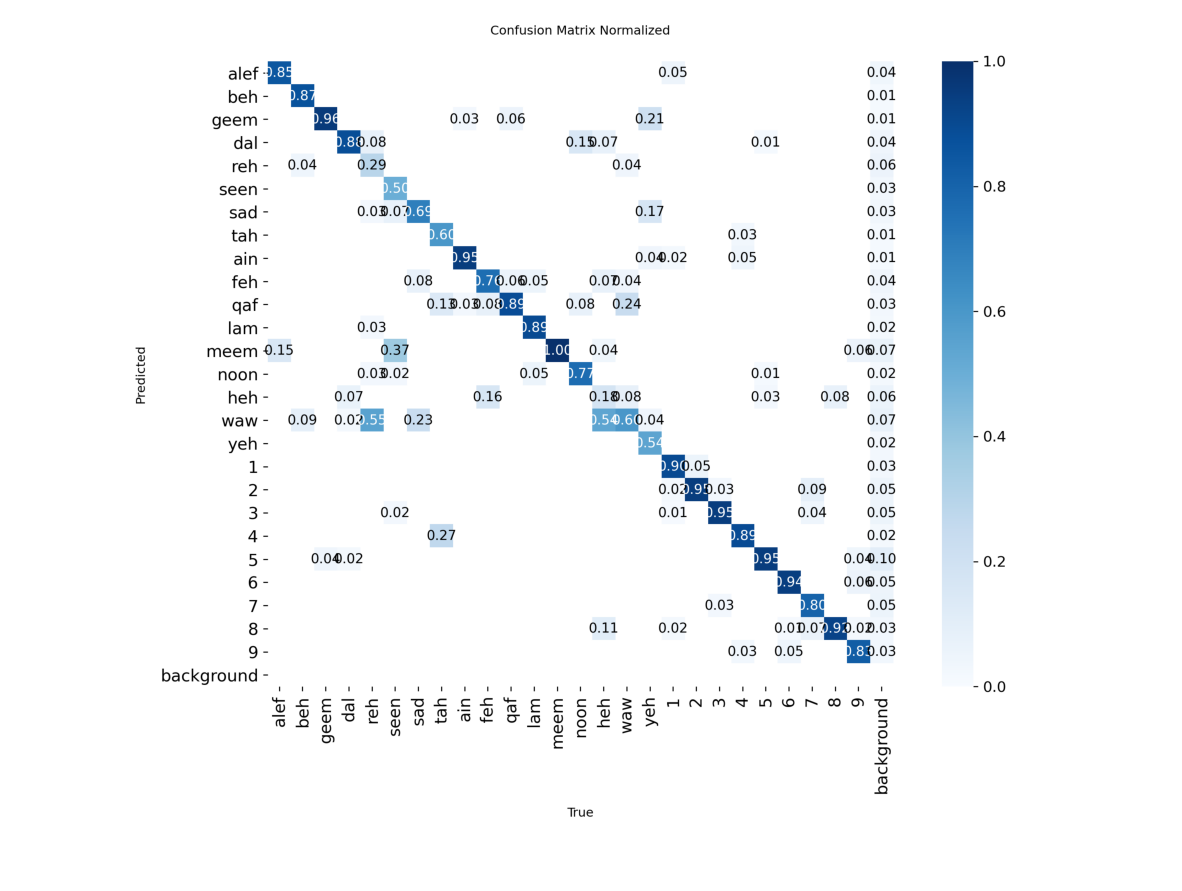

In [129]:
cm = plt.imread(f"{char_metrics.save_dir}/confusion_matrix_normalized.png")

plt.figure(figsize=(15, 15))
plt.imshow(cm)
plt.axis("off")
plt.show()

Turn character boxes on plates to a string

In [130]:
arabic = {i:c for i,c in enumerate(new_classes)}

def boxes_to_text(ids,xcs):
  # Get digit characters -  read left -> right according to xc
  digits = sorted([(x,i) for i,x in zip(ids,xcs) if arabic[i].isdigit()])

  # Get letters characters - read Right > Left:
  letters = sorted([(x,i) for i,x in zip(ids,xcs) if not arabic[i].isdigit()], reverse = True)

  # Get whole plate characters: ex:  أ س ر ١ ٤ ٧
  return "".join(arabic[i] for x,i in letters) + "".join(arabic[i] for x,i in digits)

def read_plate(model,img):
  r = model(img, conf = 0.4, agnostic_nms = True, verbose = False)[0]
  ids = r.boxes.cls.int().tolist()
  xcs = r.boxes.xywhn[:, 0].tolist()
  conf = r.boxes.conf.mean().item() if len(ids) > 0 else 0
  return boxes_to_text(ids,xcs), conf

CER 'Character Error Rate'

In [131]:
def edit_distance(a, b):  # a: truth, b: predicted
  # build the empty table: (len(a) + 1) rows × (len(b) + 1) columns
  d = []
  for i in range(len(a) + 1):
    row = []
    for j in range(len(b) + 1):
      if i == 0 or j == 0:      # first row or first column
        row.append(i + j)       # 0, 1, 2, 3 ...
      else:
        row.append(0)           # placeholder, will be filled below
    d.append(row)

  # fill every other cell
  for i in range(1, len(a) + 1):
    for j in range(1, len(b) + 1):
      deletion = d[i - 1][j] + 1       # from above
      insertion = d[i][j - 1] + 1      # from the left

      if a[i - 1] == b[j - 1]:         # same character
        match = d[i - 1][j - 1]
      else:                            # different character
        match = d[i - 1][j - 1] + 1

      d[i][j] = min(deletion, insertion, match)

  return d[len(a)][len(b)]

In [132]:
test_plates = plates[plates['split'] == 'test']
rows  = []    # to collect result for plate

for _, p in test_plates.iterrows():
  # get the true value
  b = char_boxes[char_boxes["name"] == p["name"]]
  truth = boxes_to_text(b['new_id'].astype(int).tolist(), b['xc'].tolist())

  img = cv2.imread(os.path.join(plate_img, p["file"]))
  pred , conf = read_plate(char_model, img)

  rows.append({"name": p["name"],
               "truth": truth,
               "yolo": pred,
               "yolo_cer": edit_distance(truth, pred) / len(truth)})
  ocr = pd.DataFrame(rows)

print(f"YOLO   CER: {ocr['yolo_cer'].mean():.3f}   exact match: {(ocr['truth'] == ocr['yolo']).mean():.3f}")

YOLO   CER: 0.048   exact match: 0.937


Baseline - EasyOCR on the same plates

In [133]:
# Import the ready made OCR tool (EasyOCR) to compare with YOLO results
import easyocr

In [134]:
# reader = easyocr.Reader(["ar"])
# # EasyOCR writes some letters in their common form, mapping them to the plate form
# same_letter = {"ه": "ھ", "ي": "ى", "ا": "أ", "إ": "أ", "آ": "أ"}
# allowed_letters = "".join(new_classes) + "".join(same_letter)

# def clean(text):
#     text = "".join(same_letter.get(c, c) for c in text)
#     return "".join(c for c in text if c in new_classes)

# def easyocr_read(file):
#   img = cv2.imread(os.path.join(plate_img, file))
#   img = img[int(img.shape[0] * 0.43):]       # remove the "EGYPT مصر" band ~ roughly 35~45% , with trials 43% gave best result for test dataset
#   pieces = reader.readtext(img, detail=0, allowlist=allowed_letters)
#   return clean("".join(pieces))

# # in the ocr table add column for the easyocr output and its cer :
# ocr["easyocr"] = [easyocr_read(f) for f in test_plates["file"]]
# ocr["easyocr_cer"] = [edit_distance(t, p) / len(t) for t, p in zip(ocr["truth"], ocr["easyocr"])]

# print(f"EasyOCR CER: {ocr['easyocr_cer'].mean():.3f}   exact match: {(ocr['truth'] == ocr['easyocr']).mean():.3f}")


In [137]:
reader = easyocr.Reader(["ar"])
# EasyOCR writes some letters in their common form, mapping them to the plate form
same_letter = {"ه": "ھ", "ي": "ى", "ا": "أ", "إ": "أ", "آ": "أ"}
allowed_letters = "".join(new_classes) + "".join(same_letter)

def clean(text):
  text = "".join(same_letter.get(c, c) for c in text)
  return "".join(c for c in text if c in new_classes)

def to_plate_order(text):
  # EasyOCR joins pieces left -> right, so digits (left side of the plate) come first
  letters = "".join(c for c in text if not c.isdigit())
  digits = "".join(c for c in text if c.isdigit())       # '١'.isdigit() is True
  return letters + digits                                # same format as the truth

def easyocr_read(file):
  img = cv2.imread(os.path.join(plate_img, file))
  img = img[int(img.shape[0] * 0.43):]                   # remove the "EGYPT مصر" band
  pieces = reader.readtext(img, detail=0, allowlist=allowed_letters)
  return clean("".join(pieces))

# in the ocr table add columns for the easyocr output and its cer :
ocr["easyocr_raw"] = [easyocr_read(f) for f in test_plates["file"]]       # EasyOCR's own order
ocr["easyocr"] = [to_plate_order(t) for t in ocr["easyocr_raw"]]          # letters + digits

ocr["easyocr_raw_cer"] = [edit_distance(t, p) / len(t) for t, p in zip(ocr["truth"], ocr["easyocr_raw"])]
ocr["easyocr_cer"] = [edit_distance(t, p) / len(t) for t, p in zip(ocr["truth"], ocr["easyocr"])]

print(f"EasyOCR raw order   CER: {ocr['easyocr_raw_cer'].mean():.3f}     exact match: {(ocr['truth'] == ocr['easyocr_raw']).mean():.3f}")
print(f"EasyOCR fixed order CER: {ocr['easyocr_cer'].mean():.3f}   exact match: {(ocr['truth'] == ocr['easyocr']).mean():.3f}")
#print(ocr[["truth", "easyocr_raw", "easyocr", "yolo"]].head(10))

EasyOCR raw order   CER: 0.528     exact match: 0.179
EasyOCR fixed order CER: 0.485   exact match: 0.221
